Block1_Setup

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix

# --- 1. THE CONSULTING INTERVIEW (INPUTS) ---
CLV = 500                  # Profit we lose if a customer churns
RETENTION_COST = 50        # Cost of the "Save" offer
SUCCESS_RATE = 0.5         # Probability the offer actually works

print("--- [OUTPUT 1] FINANCIAL CONTEXT ESTABLISHED ---")
print(f"Customer Lifetime Value (CLV): ${CLV}")
print(f"Cost to intervene: ${RETENTION_COST}")
print(f"Campaign Success Probability: {SUCCESS_RATE*100}%")

--- [OUTPUT 1] FINANCIAL CONTEXT ESTABLISHED ---
Customer Lifetime Value (CLV): $500
Cost to intervene: $50
Campaign Success Probability: 50.0%


Block-2_DataLoad

In [5]:
# --- 2. LOAD, CLEAN & BALANCE DATA (SMOTE) ---
from imblearn.over_sampling import SMOTE # New Library for balancing

# Load Data
df = pd.read_csv('customer_churn_dataset-training-master.csv')

# Drop ID & Missing
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)
df = df.dropna()

# One-Hot Encoding
categorical_cols = ['Gender', 'Subscription Type', 'Contract Length']
existing_cat_cols = [col for col in categorical_cols if col in df.columns]
df_encoded = pd.get_dummies(df, columns=existing_cat_cols, drop_first=True)

# Define Features (X) and Target (y)
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- NEW STEP: APPLY SMOTE (Fix Bias) ---
# We only apply SMOTE to the TRAINING data. Never the Test data.
print(f"Original Training Balance: {y_train.value_counts(normalize=True).to_dict()}")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"New SMOTE Training Balance: {y_train_resampled.value_counts(normalize=True).to_dict()}")

# Scale Data (Fit on the NEW balanced data)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled) # Fit on balanced train
X_test_scaled = scaler.transform(X_test) # Transform original test

# IMPORTANT: Update variables for Block 3 to use the resampled data
X_train = X_train_resampled
y_train = y_train_resampled

Original Training Balance: {1.0: 0.5671075950264415, 0.0: 0.43289240497355846}
New SMOTE Training Balance: {0.0: 0.5, 1.0: 0.5}


Block-3_Training 

In [6]:
# --- 3. TRAIN ENSEMBLE MODEL ---
print("Training the 'Board of Directors' (Ensemble Model)... please wait.")

# Expert 1: Logistic Regression
clf_lr = LogisticRegression(random_state=42, max_iter=1000)
# Expert 2: Random Forest
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42)
# Expert 3: XGBoost
clf_xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Voting Classifier (The Board)
ensemble_model = VotingClassifier(
    estimators=[('lr', clf_lr), ('rf', clf_rf), ('xgb', clf_xgb)],
    voting='soft'
)

ensemble_model.fit(X_train_scaled, y_train)
y_probs = ensemble_model.predict_proba(X_test_scaled)[:, 1]

print("Done. Risk Scores generated.")

Training the 'Board of Directors' (Ensemble Model)... please wait.


c:\Users\rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:199: UserWarning: [15:39:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Done. Risk Scores generated.


Block-4_Calculations

In [7]:
# --- 4. PROFIT OPTIMIZATION ENGINE ---
def calculate_net_profit(y_true, y_prob, threshold, clv, cost, success_rate):
    predictions = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, predictions).ravel()
    
    # Financial Formula
    revenue_saved = tp * clv * success_rate
    marketing_spend = (tp + fp) * cost
    
    return revenue_saved - marketing_spend

thresholds = np.arange(0.0, 1.0, 0.05)
profits = []

for t in thresholds:
    p = calculate_net_profit(y_test, y_probs, t, CLV, RETENTION_COST, SUCCESS_RATE)
    profits.append(p)
    
print("Financial calculations complete.")

Financial calculations complete.


Block-5_Executive Outputs

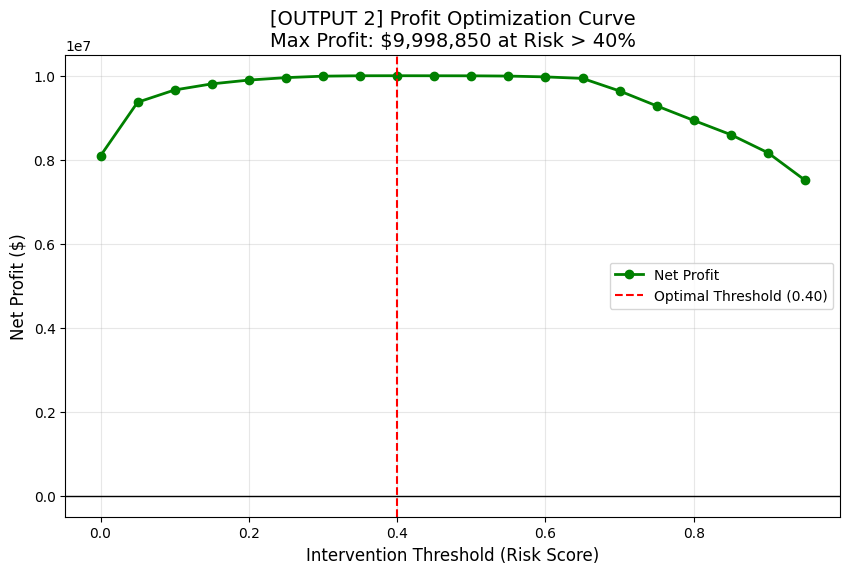


[OUTPUT 3] STRATEGIC RECOMMENDATION
1. We should target customers with a Churn Risk greater than 0.40
2. This strategy is projected to generate $9,998,850.00 in savings.
3. Compared to mass-targeting everyone, this optimizes marketing spend.

[OUTPUT 4] SAMPLE DECISIONS FOR CLIENT REVIEW
        Actual_Churn  Risk_Score Recommendation
383572           0.0    0.004487     DO NOTHING
374272           0.0    0.219218     DO NOTHING
256195           0.0    0.028859     DO NOTHING
313936           0.0    0.004883     DO NOTHING
114017           1.0    0.956915     SEND OFFER


In [8]:
# --- 5. EXECUTIVE SUMMARY ---
max_profit = max(profits)
optimal_threshold = thresholds[np.argmax(profits)]

# [OUTPUT 2] THE PROFIT CURVE (Green Line)
plt.figure(figsize=(10, 6))
plt.plot(thresholds, profits, marker='o', color='green', linewidth=2, label='Net Profit')
plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Optimal Threshold ({optimal_threshold:.2f})')
plt.axhline(y=0, color='black', linewidth=1)
plt.title(f"[OUTPUT 2] Profit Optimization Curve\nMax Profit: ${max_profit:,.0f} at Risk > {int(optimal_threshold*100)}%", fontsize=14)
plt.xlabel("Intervention Threshold (Risk Score)", fontsize=12)
plt.ylabel("Net Profit ($)", fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# [OUTPUT 3] STRATEGIC RECOMMENDATION
print("\n" + "="*50)
print("[OUTPUT 3] STRATEGIC RECOMMENDATION")
print("="*50)
print(f"1. We should target customers with a Churn Risk greater than {optimal_threshold:.2f}")
print(f"2. This strategy is projected to generate ${max_profit:,.2f} in savings.")
print(f"3. Compared to mass-targeting everyone, this optimizes marketing spend.")

# [OUTPUT 4] ACTION LIST
results = pd.DataFrame({'Actual_Churn': y_test, 'Risk_Score': y_probs})
results['Recommendation'] = results['Risk_Score'].apply(
    lambda x: 'SEND OFFER' if x >= optimal_threshold else 'DO NOTHING'
)
print("\n[OUTPUT 4] SAMPLE DECISIONS FOR CLIENT REVIEW")
print(results.sample(5))

Block-6_Deep Dive

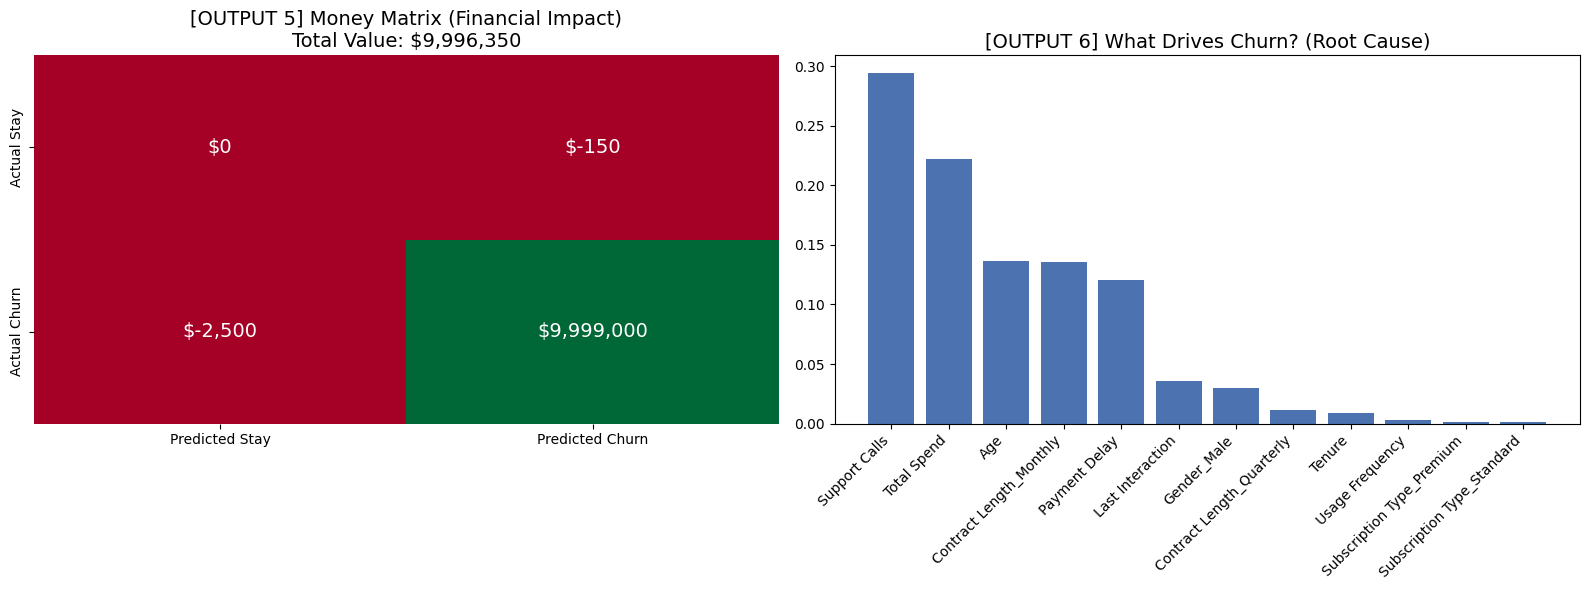

In [9]:
# --- 6. DEEP DIVE DIAGNOSTICS ---

# Calculate Logic for Money Matrix
y_pred_optimal = (y_probs >= optimal_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_optimal)

# Calculate Dollar Value for each quadrant
money_matrix = np.array([
    [0,                                      cm[0,1] * (-RETENTION_COST)],      
    [cm[1,0] * (-CLV),                       cm[1,1] * ((CLV * SUCCESS_RATE) - RETENTION_COST)] 
])

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# [OUTPUT 5] MONEY MATRIX
sns.heatmap(money_matrix, annot=True, fmt='g', cmap='RdYlGn', ax=ax[0], cbar=False, annot_kws={"size": 14})
ax[0].set_title(f"[OUTPUT 5] Money Matrix (Financial Impact)\nTotal Value: ${money_matrix.sum():,.0f}", fontsize=14)
ax[0].set_xticklabels(['Predicted Stay', 'Predicted Churn'])
ax[0].set_yticklabels(['Actual Stay', 'Actual Churn'])
for t in ax[0].texts: t.set_text(f"${float(t.get_text()):,.0f}")

# [OUTPUT 6] ROOT CAUSE ANALYSIS (Feature Importance)
# Extract feature importance from the Random Forest part of the ensemble
rf_model = ensemble_model.named_estimators_['rf']
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

ax[1].set_title("[OUTPUT 6] What Drives Churn? (Root Cause)", fontsize=14)
ax[1].bar(range(X_train.shape[1]), importances[indices], align="center", color='#4c72b0')
ax[1].set_xticks(range(X_train.shape[1]))
ax[1].set_xticklabels([X.columns[i] for i in indices], rotation=45, ha='right')

plt.tight_layout()
plt.show()

Block-7_SHAP

c:\Users\rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Analyzing Customer #5
Model Prediction: 1.0 (0=Stay, 1=Churn)


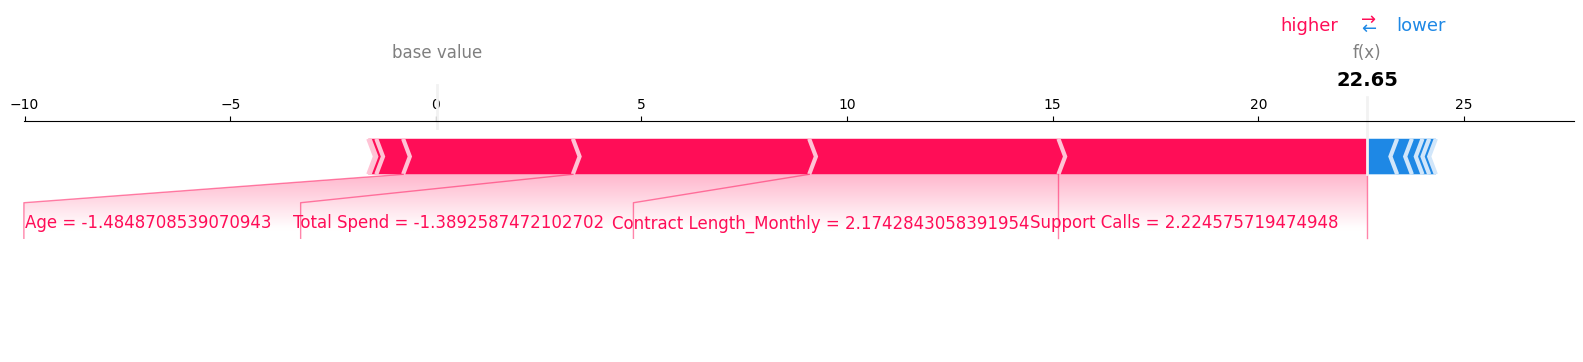

In [10]:
# --- 7. EXPLAINABILITY ENGINE (SHAP) ---
import shap

# 1. Select the "Expert" to explain (XGBoost works best with SHAP)
# We extract just the XGBoost model from your Ensemble
model_to_explain = ensemble_model.named_estimators_['xgb']

# 2. Create the Explainer
# This calculates how much each feature contributes to the prediction
explainer = shap.TreeExplainer(model_to_explain)
shap_values = explainer.shap_values(X_test_scaled)

# 3. Choose a Specific Customer to Analyze
# Let's pick a high-risk customer from the test set (e.g., index 5)
customer_idx = 5 

# Display their actual risk score
print(f"Analyzing Customer #{customer_idx}")
print(f"Model Prediction: {ensemble_model.predict([X_test_scaled[customer_idx]])[0]} (0=Stay, 1=Churn)")

# 4. Generate the Force Plot
# This visualizes the "Tug of War" between features
shap.initjs() # Initialize JavaScript for the plot
shap.force_plot(
    base_value=explainer.expected_value, 
    shap_values=shap_values[customer_idx,:], 
    features=X_test_scaled[customer_idx,:], 
    feature_names=X.columns,
    matplotlib=True # Set to False if using interactive Jupyter, True for static image
)

Block-8_Clustering (Segementation)

--- [OUTPUT 7] CLUSTER SEGMENTATION SUMMARY ---
            Tenure  Contract Length_Monthly
Cluster                                    
0        40.547863                 0.349101
1         9.082692                 0.345513
2        25.507127                 0.341860
3        54.019271                 0.345332


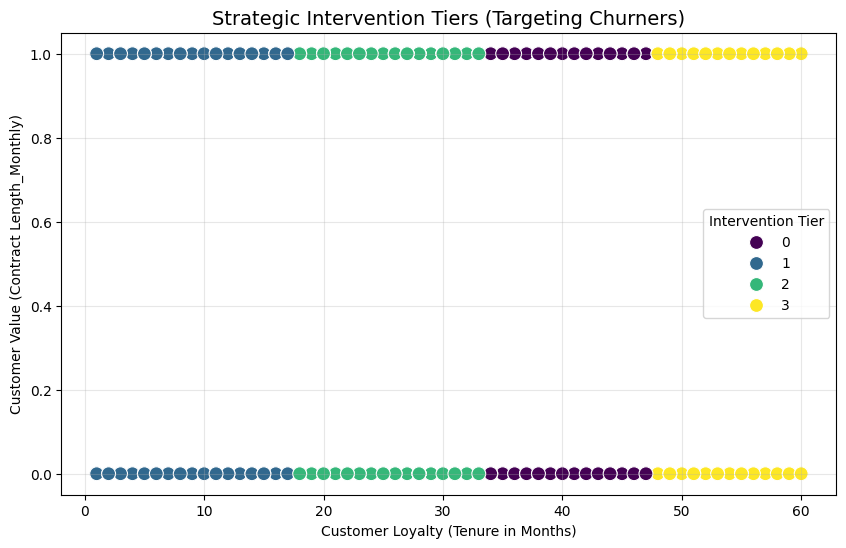

--- STRATEGY GUIDE ---
Top Right Cluster (High Tenure/High Value): 'VIP Intervention' -> Call them immediately + Big Discount
Bottom Left Cluster (Low Tenure/Low Value): 'Low Priority' -> Send automated email


In [11]:
# --- 8. STRATEGIC SEGMENTATION (CLUSTERING) ---
import numpy as np
from sklearn.cluster import KMeans

# 1. Filter: Get only the customers predicted to churn
churn_indices = np.where(y_probs >= optimal_threshold)[0]
churn_customers = X_test.iloc[churn_indices].copy()

# 2. Select Business Features for Clustering
# We cluster based on 'Tenure' (Loyalty) and 'Contract Length_Monthly' (Value)
# Note: Using 'Contract Length_Monthly' as requested
cluster_features = ['Tenure', 'Contract Length_Monthly'] 
X_cluster = churn_customers[cluster_features]

# 3. Apply K-Means Clustering (Create 4 Tiers)
kmeans = KMeans(n_clusters=4, random_state=42)
churn_customers['Cluster'] = kmeans.fit_predict(X_cluster)

# 4. Define Strategies based on Clusters
# We calculate the average value of each cluster to name them
cluster_summary = churn_customers.groupby('Cluster')[cluster_features].mean()
print("--- [OUTPUT 7] CLUSTER SEGMENTATION SUMMARY ---")
print(cluster_summary)

# 5. Visualize the Strategy (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=churn_customers, x='Tenure', y='Contract Length_Monthly', hue='Cluster', palette='viridis', s=100
)
plt.title('Strategic Intervention Tiers (Targeting Churners)', fontsize=14)
plt.xlabel('Customer Loyalty (Tenure in Months)')
plt.ylabel('Customer Value (Contract Length_Monthly)')
plt.legend(title='Intervention Tier')
plt.grid(True, alpha=0.3)
plt.show()

print("--- STRATEGY GUIDE ---")
print("Top Right Cluster (High Tenure/High Value): 'VIP Intervention' -> Call them immediately + Big Discount")
print("Bottom Left Cluster (Low Tenure/Low Value): 'Low Priority' -> Send automated email")